In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("Week 8 Skill: XGBoost, LightGBM and SHAP")

Week 8 Skill: XGBoost, LightGBM and SHAP


In [114]:
df = pd.read_csv('/content/placement_predict_50k.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0


In [115]:
df = df.drop(columns=['IsAnomaly'], errors='ignore')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [116]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (50000, 45)
Target: (50000,)


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 45)
Testing data: (10000, 45)


In [118]:
!pip install -q xgboost lightgbm shap

print("Libraries installed successfully")

Libraries installed successfully


In [119]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.7886


In [120]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

print("LightGBM Accuracy:",
      accuracy_score(y_test, lgb_pred))

LightGBM Accuracy: 0.7892


In [121]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred)
    ]
})

print(results)

      Model  Accuracy
0   XGBoost    0.7886
1  LightGBM    0.7892


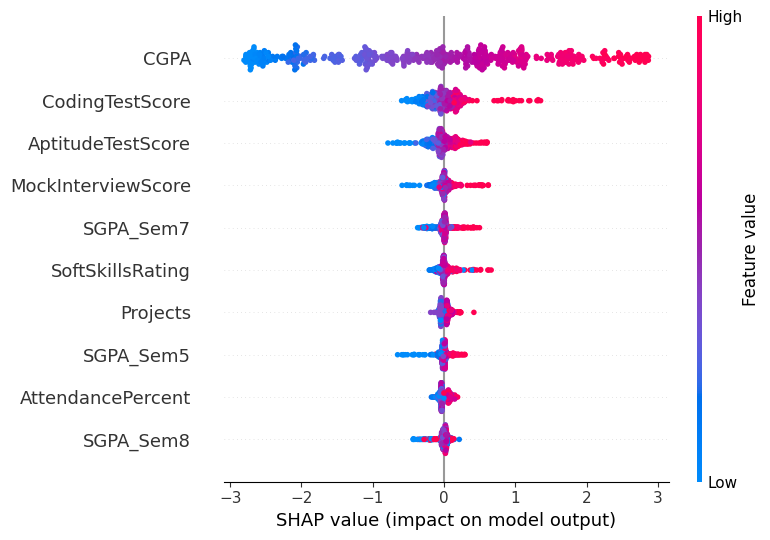

In [122]:
import shap

explainer = shap.TreeExplainer(xgb_model)

# Use a small sample to keep SHAP fast
X_sample = X_test.iloc[:500]

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    max_display=10
)

Most important feature: CGPA


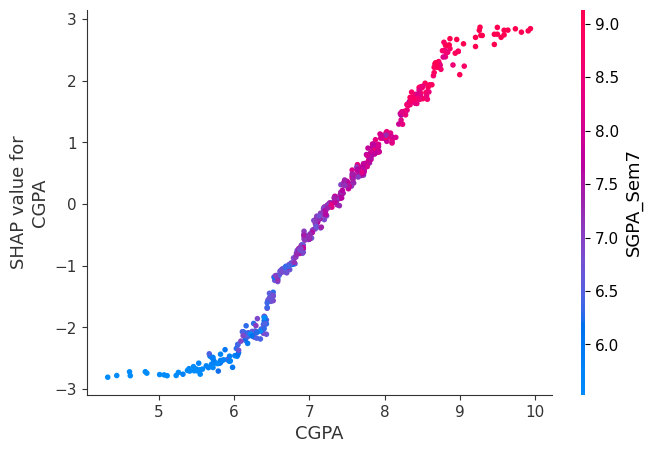

In [123]:
# Get the most important feature
mean_importance = np.abs(shap_values).mean(axis=0)
top_feature_index = np.argmax(mean_importance)
top_feature = X_sample.columns[top_feature_index]

print("Most important feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_sample
)

In [124]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred)
    ]
})

print(comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True))

           Model  Accuracy
0  Random Forest    0.7909
1       LightGBM    0.7892
2        XGBoost    0.7886


In [125]:
comparison.to_csv(
    "week_8_results.csv",
    index=False
)

print("Week 8 results saved successfully!")

Week 8 results saved successfully!
